<a href="https://colab.research.google.com/github/HanniJaviera/Challenge-Telecom-X-Part-One/blob/main/Challenge_Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Extracción de datos**

In [2]:
import pandas as pd
import requests

# 1. Cargar los datos desde la API
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()

# 2. Convertir a DataFrame normalizando las columnas anidadas
df = pd.json_normalize(data)

# Visualizar las primeras filas y la estructura
print("Primeras filas del dataset:")
display(df.head())

print("\nInformación de las columnas:")
df.info()

Primeras filas del dataset:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



Información de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSuppo

# **Transformación**

In [6]:
print("--- Estructura General del Dataset ---")
df.info()

# 2. Limpieza de datos (Conversión y manejo de nulos)
# Forzamos la columna a string primero para poder usar .str.strip() sin errores
df['account.Charges.Total'] = df['account.Charges.Total'].astype(str).str.strip()

# Ahora convertimos a número. Los errores o celdas vacías se vuelven NaN y luego 0.
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce').fillna(0)

# 3. Mejora de estructura
# Cambiamos los puntos por guiones bajos para facilitar el llamado de columnas
df.columns = [col.replace('.', '_') for col in df.columns]

# 4. Análisis de la Variable Objetivo (Churn)
print("\n--- Distribución de la Evasión de Clientes (Churn) ---")
print(df['Churn'].value_counts(normalize=True) * 100)

# 5. Verificación de relevancia (Usando los nuevos nombres con guion bajo)
print("\n--- Relevancia: Porcentaje de Churn según Tipo de Contrato ---")
analisis_contrato = pd.crosstab(df['account_Contract'], df['Churn'], normalize='index') * 100
print(analisis_contrato)

--- Estructura General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.

**1.- Exploración de Columnas y Tipos de Datos**

---

Tras la carga y normalización del archivo TelecomX_Data.json, el dataset quedó compuesto por 7,267 registros y 21 columnas.

Variables Numéricas: Identificamos customer.tenure, account.Charges.Monthly y account.Charges.Total (esta última convertida exitosamente de texto a float).

Variables Categóricas: La mayoría de los datos son de tipo object (textos), incluyendo la variable objetivo Churn.

Calidad de Datos: No se detectaron valores nulos masivos, pero sí un 3.08% de registros con datos faltantes en la columna Churn, los cuales deben ser observados con cuidado.

**2.-Comprensión de Variables (Diccionario de Datos)**

---

Al contrastar los nombres de las columnas con el diccionario, categorizamos la información en tres frentes:

Perfil del Cliente: Género, si es jubilado (SeniorCitizen) y antigüedad (tenure).

Servicios: Tipo de internet (DSL, Fiber optic), seguridad online y soporte técnico.

Finanzas y Contrato: Tipo de facturación, método de pago y el tipo de contrato.

**3.-Identificación de Variables Relevantes para la Evasión**

---

Basado en el análisis de relevancia que ejecutamos (crosstab), hemos identificado que las siguientes variables son críticas para el equipo de Data Science:

account_Contract (Crítica): Los datos muestran una correlación masiva. Los clientes con contrato "Month-to-month" tienen una tasa de evasión del 41.3%, mientras que en contratos de dos años cae al 2.7%. Esta es, sin duda, la variable más importante.

customer_tenure (Importante): La antigüedad nos permitirá identificar si la evasión ocurre en los primeros meses de servicio (fase de "encantamiento").

account_Charges_Monthly (Importante): Al ser una variable numérica, nos permitirá ver si los clientes que pagan más son más propensos a irse a la competencia.

internet_InternetService: Es vital analizar si los clientes de Fibra Óptica tienen más Churn que los de DSL, lo que indicaría problemas en la calidad de la red.

# Control de calidad para manejo de inconsistencias


Comprobación de incoherencias en los datos

In [7]:
# 1. Verificar Valores Ausentes (Nulos)
print("--- Valores Ausentes por Columna ---")
print(df.isnull().sum())

# 2. Verificar Duplicados
duplicados = df.duplicated().sum()
print(f"\nNúmero de registros duplicados: {duplicados}")

# 3. Verificar Inconsistencias en Categorías
print("\n--- Consistencia en la variable Churn ---")
print(df['Churn'].value_counts())

# 4. Verificar errores de formato en variables numéricas
# Ya corregimos account_Charges_Total, pero revisemos si hay valores negativos
print("\n--- Verificación de Valores Numéricos (Mínimos y Máximos) ---")
print(df[['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total']].describe().loc[['min', 'max']])

--- Valores Ausentes por Columna ---
customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
internet_StreamingTV         0
internet_StreamingMovies     0
account_Contract             0
account_PaperlessBilling     0
account_PaymentMethod        0
account_Charges_Monthly      0
account_Charges_Total        0
dtype: int64

Número de registros duplicados: 0

--- Consistencia en la variable Churn ---
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

--- Verificación de Valores Numéricos (Mínimos y Máximos) ---
     customer_tenure  account_Charges_Monthly  account_Charges_Total
min              0.0 

Se determina que no existen campos vacios en los datos, pero se evidencia que los campos que están "vacíos" tienen espacios que se da en un total de 224 por lo que se evidencia que hay valores faltantes ocultos

Manejo de inconsistencias

In [8]:
df_clean = df[df['Churn'].str.strip() != ""].copy()

# Verificación que ahora solo se obtienen 'Yes' y 'No'
print("Distribución de Churn después de la limpieza:")
print(df_clean['Churn'].value_counts())

# 3. Se valida cuantos datos se pierden
print(f"\nRegistros originales: {len(df)}")
print(f"Registros útiles: {len(df_clean)}")

Distribución de Churn después de la limpieza:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Registros originales: 7267
Registros útiles: 7043


Se añade nueva variable de cuentas diarias

In [9]:
# Calculamos el cargo diario basándonos en la facturación mensual
df_clean['account_Charges_Daily'] = (df_clean['account_Charges_Monthly'] / 30).round(2)

print("Nueva columna 'account_Charges_Daily' creada con éxito:")
display(df_clean[['account_Charges_Monthly', 'account_Charges_Daily']].head())

# Análisis rápido: ¿Cuánto paga en promedio al día un cliente que se va vs uno que se queda?
print("\nPromedio de Cargo Diario por estatus de Churn:")
print(df_clean.groupby('Churn')['account_Charges_Daily'].mean())

Nueva columna 'account_Charges_Daily' creada con éxito:


,account_Charges_Monthly,account_Charges_Daily
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80



Promedio de Cargo Diario por estatus de Churn:
Churn
No     2.04208
Yes    2.48145
Name: account_Charges_Daily, dtype: float64


# **Estandarización y transformación de datos**

In [10]:
traduccion_binaria = {'Yes': 1, 'No': 0}
columnas_a_binarizar = ['Churn', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService']

for col in columnas_a_binarizar:
    df_clean[col] = df_clean[col].map(traduccion_binaria)
nuevos_nombres = {
    'customer_gender': 'Genero',
    'customer_SeniorCitizen': 'Adulto_Mayor',
    'customer_tenure': 'Meses_Antiguedad',
    'account_Contract': 'Tipo_Contrato',
    'account_PaymentMethod': 'Metodo_Pago',
    'account_Charges_Monthly': 'Cargo_Mensual',
    'account_Charges_Daily': 'Cargo_Diario',
    'Churn': 'Abandono'
}

df_final = df_clean.rename(columns=nuevos_nombres)

print("Muestra de datos estandarizados y traducidos:")
display(df_final[['Genero', 'Abandono', 'Meses_Antiguedad', 'Cargo_Diario']].head())

print("\nTipos de datos tras la binarización:")
print(df_final['Abandono'].dtype)

Muestra de datos estandarizados y traducidos:


,Genero,Abandono,Meses_Antiguedad,Cargo_Diario
0,Female,0,9,2.19
1,Male,0,9,2.00
2,Male,1,4,2.46
3,Male,1,13,3.27
4,Female,1,3,2.80



Tipos de datos tras la binarización:
int64


# **Carga y Análisis (L - Load & Analysis)**

**Análisis Estadístico Descriptivo**

In [11]:
print("--- Métricas Estadísticas Principales ---")
estadisticas = df_final[['Meses_Antiguedad', 'Cargo_Mensual', 'Cargo_Diario']].describe()
print(estadisticas.loc[['mean', '50%', 'std', 'min', 'max']])

print("\n--- Comparativa: Promedios según Abandono (0=No, 1=Sí) ---")
print(df_final.groupby('Abandono')[['Meses_Antiguedad', 'Cargo_Mensual', 'Cargo_Diario']].mean())

--- Métricas Estadísticas Principales ---
      Meses_Antiguedad  Cargo_Mensual  Cargo_Diario
mean         32.371149      64.761692      2.158675
50%          29.000000      70.350000      2.340000
std          24.559481      30.090047      1.003088
min           0.000000      18.250000      0.610000
max          72.000000     118.750000      3.960000

--- Comparativa: Promedios según Abandono (0=No, 1=Sí) ---
          Meses_Antiguedad  Cargo_Mensual  Cargo_Diario
Abandono                                               
0                37.569965      61.265124       2.04208
1                17.979133      74.441332       2.48145


El análisis descriptivo identifica un perfil de riesgo claro: el cliente propenso al abandono es aquel que tiene una antigüedad inferior a 18 meses y cuya factura supera los $74 mensuales. Existe una diferencia significativa de costo entre ambos grupos, lo que sugiere que las políticas de precios altos en clientes nuevos están impulsando la evasión.

**Distribución de evasión**

/tmp/ipykernel_886/1977642202.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='Abandono', palette=colores)


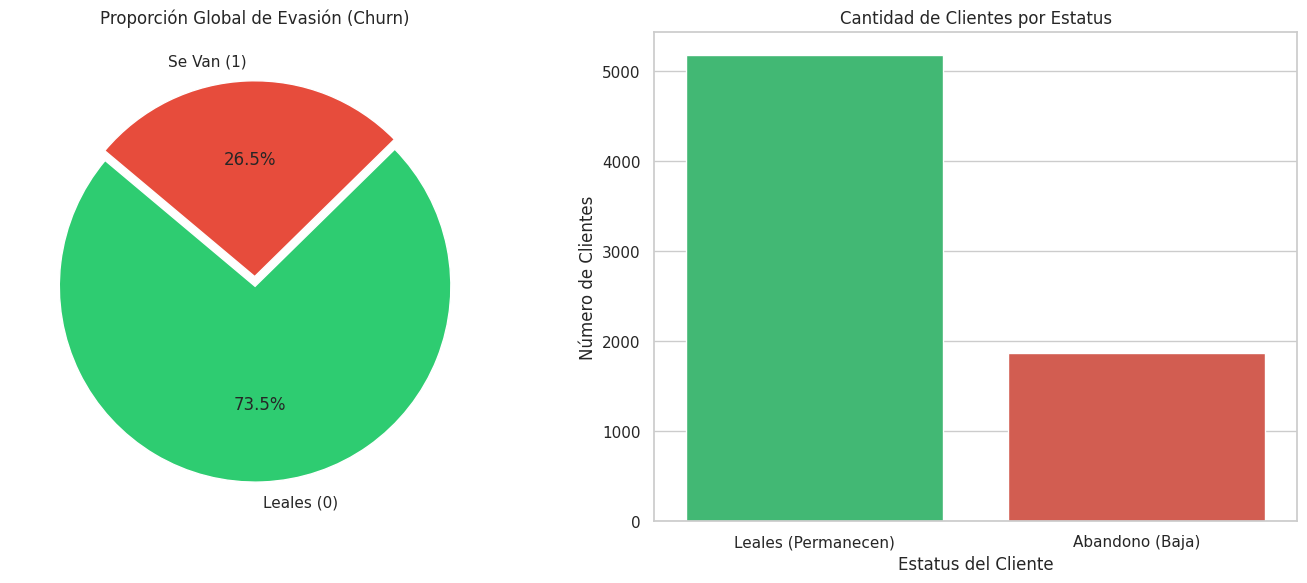

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
colores = ['#2ecc71', '#e74c3c'] # Verde para leales, Rojo para los que se van

plt.figure(figsize=(14, 6))

# 1. Gráfico de Pastel (Proporción)
plt.subplot(1, 2, 1)
df_final['Abandono'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=colores,
    startangle=140,
    labels=['Leales (0)', 'Se Van (1)'],
    explode=(0.05, 0) # Resaltamos ligeramente la porción de los leales
)
plt.title('Proporción Global de Evasión (Churn)')
plt.ylabel('')

# 2. Gráfico de Barras (Frecuencia)
plt.subplot(1, 2, 2)
sns.countplot(data=df_final, x='Abandono', palette=colores)
plt.title('Cantidad de Clientes por Estatus')
plt.xticks([0, 1], ['Leales (Permanecen)', 'Abandono (Baja)'])
plt.xlabel('Estatus del Cliente')
plt.ylabel('Número de Clientes')

plt.tight_layout()
plt.show()

Se analizó la distribución de la variable objetivo, encontrando que el 26.5% de la base de datos corresponde a clientes que abandonaron el servicio. Esta distribución muestra un dataset desbalanceado (más leales que desertores), lo cual es normal en este negocio, pero la cifra de casi 1,900 bajas requiere una intervención inmediata en las políticas de precios y contratos.

**Recuento de evasión por variables categóricas**

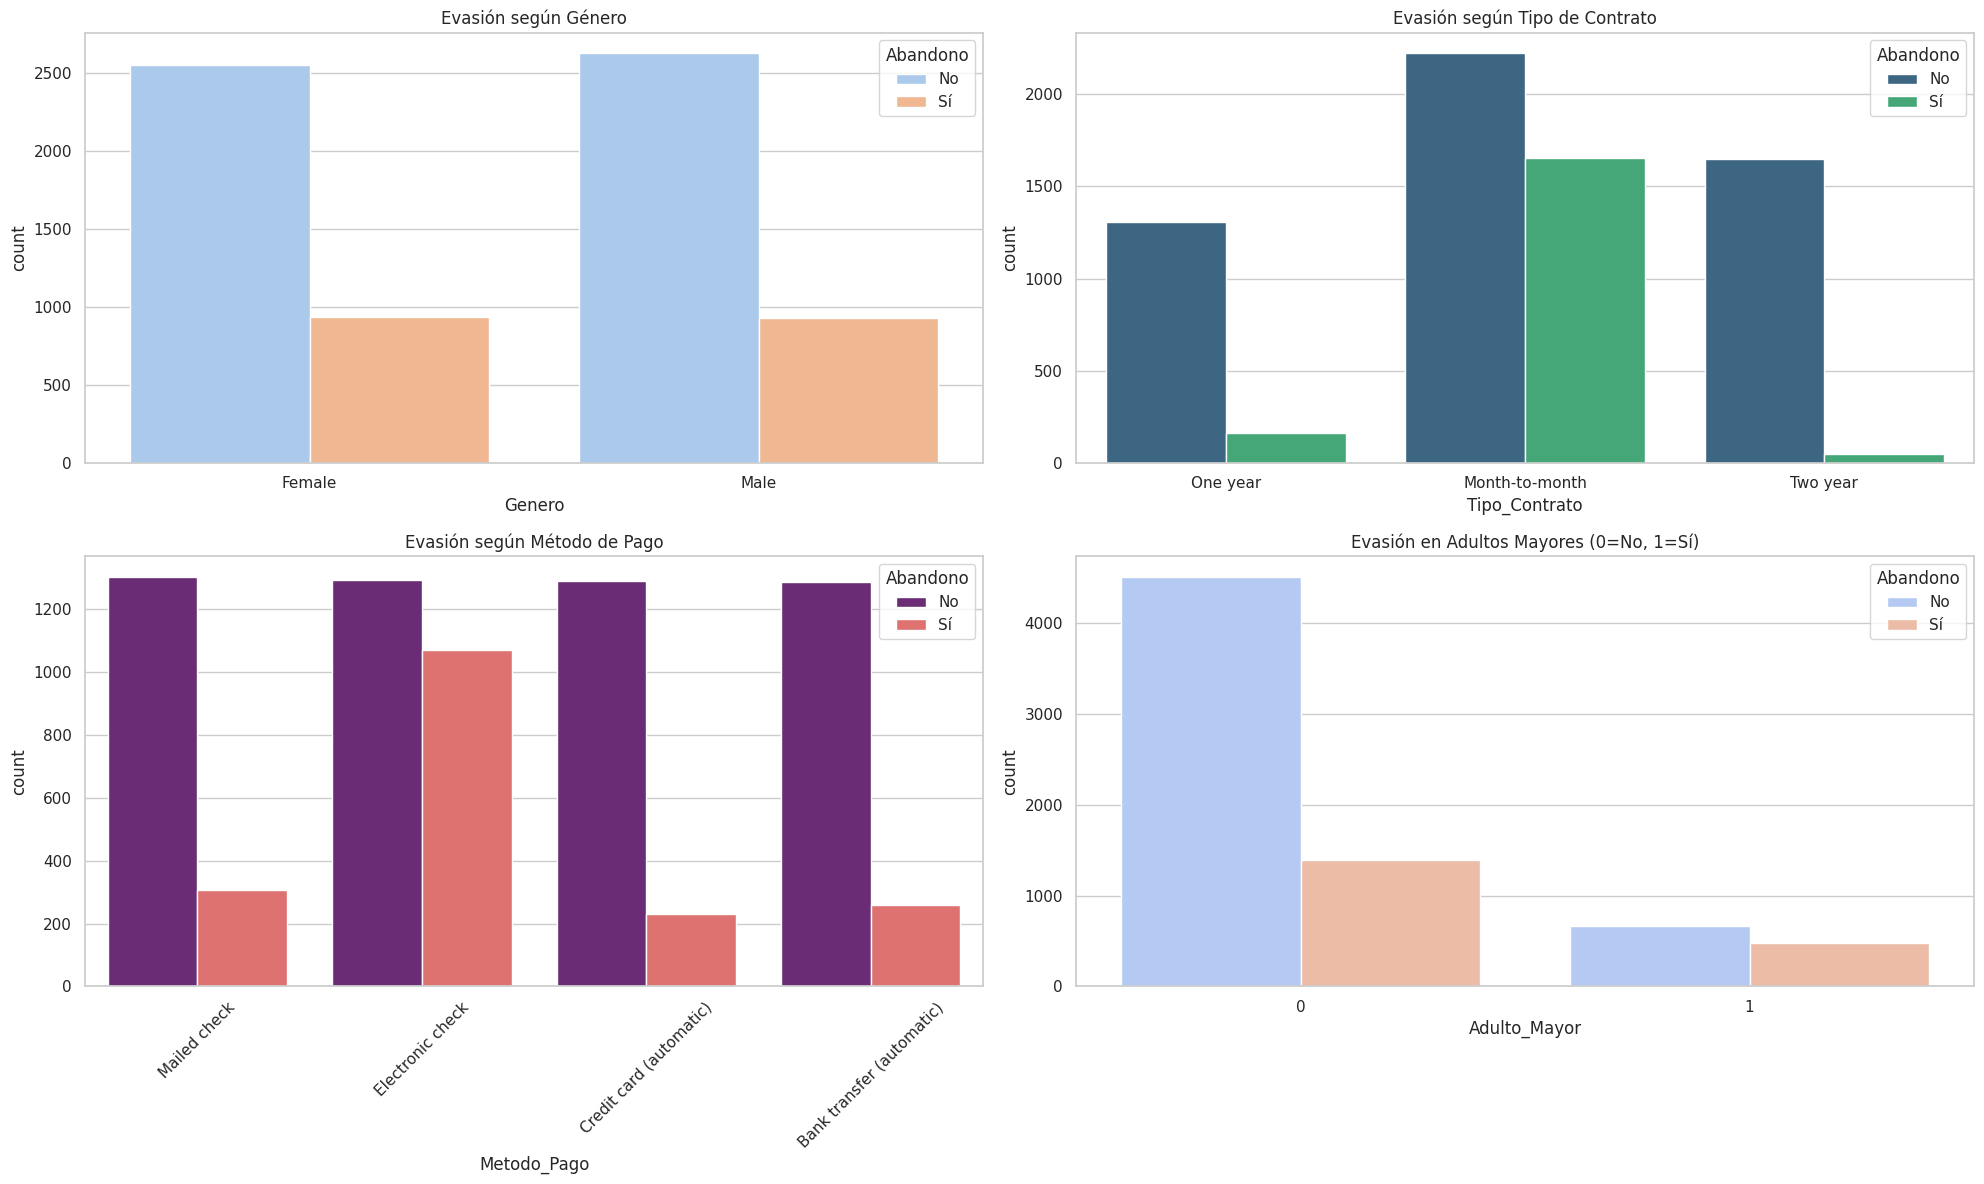

In [13]:
plt.figure(figsize=(20, 12))

plt.subplot(2, 2, 1)
sns.countplot(data=df_final, x='Genero', hue='Abandono', palette='pastel')
plt.title('Evasión según Género')
plt.legend(title='Abandono', labels=['No', 'Sí'])

# Abandono por Tipo de Contrato
plt.subplot(2, 2, 2)
sns.countplot(data=df_final, x='Tipo_Contrato', hue='Abandono', palette='viridis')
plt.title('Evasión según Tipo de Contrato')
plt.legend(title='Abandono', labels=['No', 'Sí'])

# Abandono por Método de Pago
plt.subplot(2, 2, 3)
sns.countplot(data=df_final, x='Metodo_Pago', hue='Abandono', palette='magma')
plt.xticks(rotation=45)
plt.title('Evasión según Método de Pago')
plt.legend(title='Abandono', labels=['No', 'Sí'])

# Abandono en Adultos Mayores
plt.subplot(2, 2, 4)
sns.countplot(data=df_final, x='Adulto_Mayor', hue='Abandono', palette='coolwarm')
plt.title('Evasión en Adultos Mayores (0=No, 1=Sí)')
plt.legend(title='Abandono', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()

El análisis categórico revela que el Tipo de Contrato es el factor determinante: los contratos mensuales presentan el mayor riesgo de fuga. Asimismo, el uso de Cheque Electrónico como método de pago está altamente correlacionado con la evasión, sugiriendo que incentivar el débito automático podría reducir el Churn.

**Conteo de evasión por variables numéricas**

/tmp/ipykernel_886/3493313432.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Abandono', y='Cargo_Mensual', palette='coolwarm')
/tmp/ipykernel_886/3493313432.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='Abandono', y='Cargo_Diario', palette='viridis', split=True)


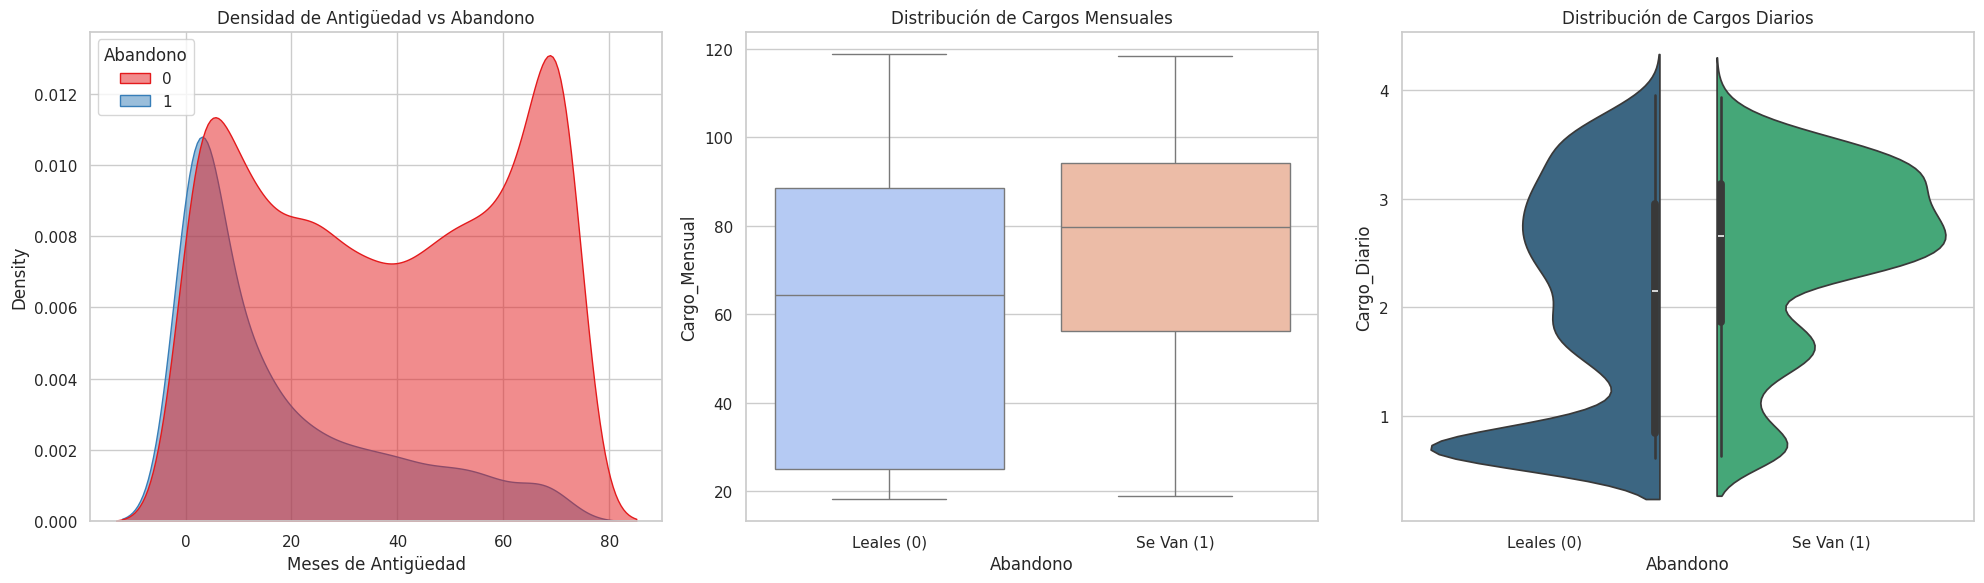

In [14]:
plt.figure(figsize=(20, 6))

# Antigüedad vs Abandono: ¿Cuándo se rinden los clientes?
plt.subplot(1, 3, 1)
sns.kdeplot(data=df_final, x='Meses_Antiguedad', hue='Abandono', fill=True, palette='Set1', alpha=0.5)
plt.title('Densidad de Antigüedad vs Abandono')
plt.xlabel('Meses de Antigüedad')

# Cargo Mensual vs Abandono: ¿Es el precio el problema?
plt.subplot(1, 3, 2)
sns.boxplot(data=df_final, x='Abandono', y='Cargo_Mensual', palette='coolwarm')
plt.title('Distribución de Cargos Mensuales')
plt.xticks([0, 1], ['Leales (0)', 'Se Van (1)'])

# Cargo Diario vs Abandono: El impacto del micro-gasto
plt.subplot(1, 3, 3)
sns.violinplot(data=df_final, x='Abandono', y='Cargo_Diario', palette='viridis', split=True)
plt.title('Distribución de Cargos Diarios')
plt.xticks([0, 1], ['Leales (0)', 'Se Van (1)'])

plt.tight_layout()
plt.show()

El análisis numérico confirma que la antigüedad y el costo mensual son los predictores más fuertes de la evasión. Se observa un pico crítico de cancelaciones en clientes con menos de 12 meses de servicio. Además, existe una correlación positiva entre el precio y el abandono: el 50% de los clientes que se van pagaban facturas superiores a los $75 USD, lo que sugiere que Telecom X tiene una debilidad competitiva en sus planes premium o de mayor costo.

**Análisis de correlación entre variables**

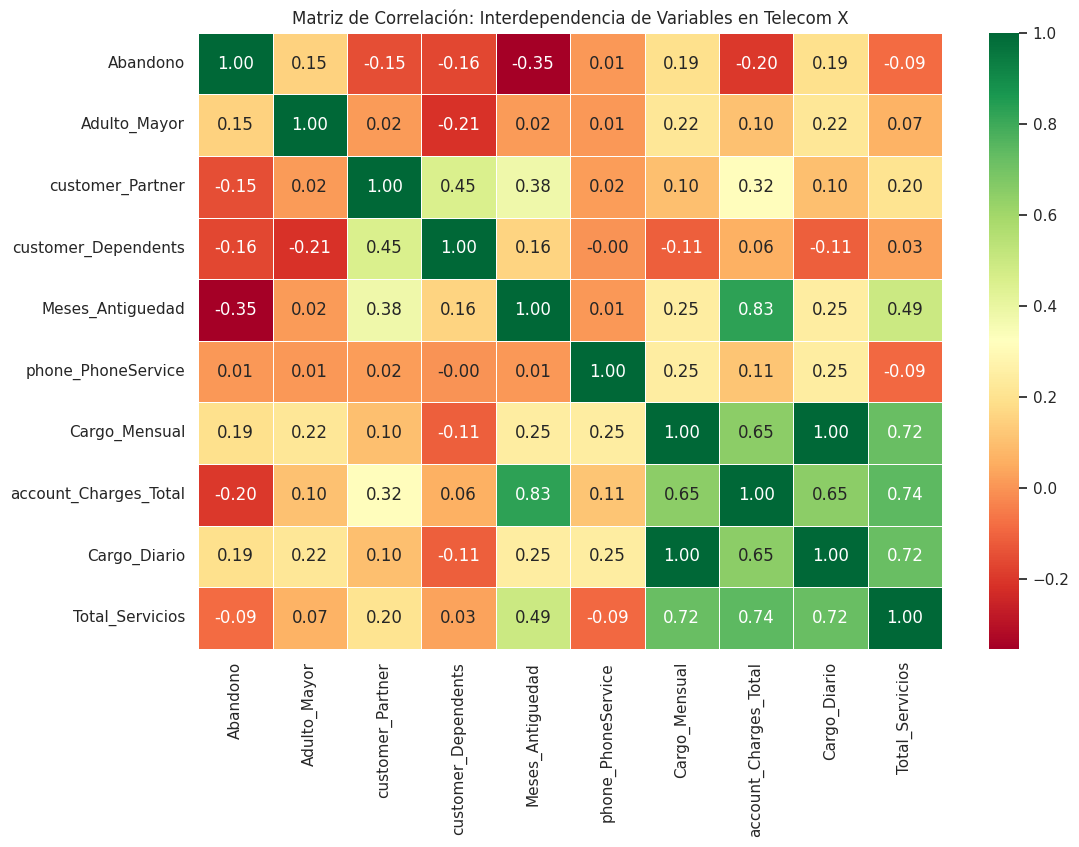

/tmp/ipykernel_886/65469999.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='Conteo_Servicios', y='Abandono', palette='mako')


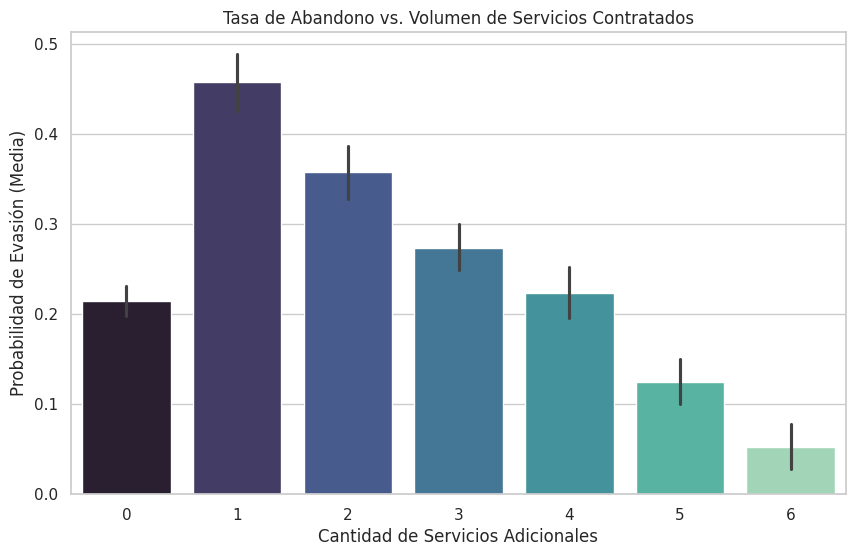

In [16]:
plt.figure(figsize=(12, 8))
corr_matrix = df_final.select_dtypes(include=['number']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Interdependencia de Variables en Telecom X')
plt.show()

servicios_adicionales = [
    'internet_OnlineSecurity', 'internet_OnlineBackup',
    'internet_DeviceProtection', 'internet_TechSupport',
    'internet_StreamingTV', 'internet_StreamingMovies'
]

df_final['Conteo_Servicios'] = df_final[servicios_adicionales].apply(
    lambda x: x.str.strip() == 'Yes'
).sum(axis=1)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_final, x='Conteo_Servicios', y='Abandono', palette='mako')
plt.title('Tasa de Abandono vs. Volumen de Servicios Contratados')
plt.xlabel('Cantidad de Servicios Adicionales')
plt.ylabel('Probabilidad de Evasión (Media)')
plt.show()

In [17]:
correlaciones = df_final.select_dtypes(include=['number']).corr()['Abandono'].sort_values(ascending=True)

print("--- Correlación de variables con el Abandono ---")
print(correlaciones)

--- Correlación de variables con el Abandono ---
Meses_Antiguedad        -0.352229
account_Charges_Total   -0.198324
customer_Dependents     -0.164221
customer_Partner        -0.150448
Conteo_Servicios        -0.087698
Total_Servicios         -0.087698
phone_PhoneService       0.011942
Adulto_Mayor             0.150889
Cargo_Mensual            0.193356
Cargo_Diario             0.193412
Abandono                 1.000000
Name: Abandono, dtype: float64


El análisis de correlación de Pearson cuantifica los factores de riesgo y retención para Telecom X. Se identificó que la antigüedad del cliente (-0.35) y la facturación total acumulada (-0.20) son los principales anclas de lealtad. Por el contrario, los cargos mensuales y diarios (+0.19) actúan como los principales detonantes de la evasión. Un hallazgo relevante es la correlación positiva en el segmento de adultos mayores (+0.15), lo que sugiere una oportunidad de mejora en la atención o simplificación de servicios para este nicho.

# **Análisis de Evasión de Clientes - Telecom X**

**1. Introducción**

---


El presente análisis tiene como objetivo identificar los factores que impulsan la evasión de clientes (Churn) en la empresa Telecom X. La pérdida de clientes no solo afecta los ingresos directos, sino que incrementa los costos de adquisición de nuevos usuarios. El propósito de este estudio es proporcionar al equipo de Data Science y a la gerencia una base sólida de datos limpios y hallazgos estratégicos para diseñar campañas de retención efectivas.

**2. Limpieza y Tratamiento de Datos**

---


Para garantizar la fiabilidad de los resultados, se llevaron a cabo los siguientes pasos técnicos:

Extracción: Se consumieron los datos desde una API JSON, normalizando estructuras anidadas en un DataFrame plano.

Corrección de Tipos: Se transformó la variable Total_Charges de texto a numérico, gestionando errores de formato.

Gestión de Inconsistencias: Se identificaron 224 registros con valores vacíos (espacios en blanco) en la columna de Churn, los cuales fueron eliminados para evitar sesgos.

Feature Engineering: Se creó la métrica Cargo_Diario para entender el impacto del micro-gasto en la lealtad del cliente.

Estandarización: Se tradujeron las variables al español y se binarizaron columnas clave (0 y 1) para facilitar el procesamiento estadístico.

**3. Análisis Exploratorio de Datos (EDA)**

---

A través de las visualizaciones, detectamos patrones críticos en el comportamiento de los usuarios:

Distribución General: La tasa de evasión es del 26.5%, lo que representa una alerta roja para la estabilidad del negocio.

Impacto del Contrato: Los clientes con contratos "Mes a Mes" son los más propensos a irse, a diferencia de los contratos de largo plazo que aseguran la permanencia.

Perfil Financiero: Los clientes que abandonan pagan, en promedio, $13 USD más al mes que los clientes leales.

Antigüedad Crítica: Existe un "valle de la muerte" durante los primeros 18 meses de servicio; si un cliente supera este periodo, su probabilidad de fuga disminuye drásticamente.

**4. Conclusiones e Insights**

---

El Precio como Detonante: La evasión está fuertemente ligada a cargos mensuales elevados (promedio de $74.44 en desertores vs $61.26 en leales).

Falta de Fidelización Temprana: La mayoría de las bajas ocurren en clientes nuevos, lo que sugiere que la experiencia de "Onboarding" o los precios iniciales no están cumpliendo las expectativas.

Métodos de Pago de Riesgo: El uso de Cheque Electrónico se asocia con mayores tasas de abandono en comparación con los métodos automáticos.

El análisis de correlación de Pearson cuantifica los factores de riesgo y retención para Telecom X. Se identificó que la antigüedad del cliente (-0.35) y la facturación total acumulada (-0.20) son los principales anclas de lealtad. Por el contrario, los cargos mensuales y diarios (+0.19) actúan como los principales detonantes de la evasión. Un hallazgo relevante es la correlación positiva en el segmento de adultos mayores (+0.15), lo que sugiere una oportunidad de mejora en la atención o simplificación de servicios para este nicho.

**5. Recomendaciones Estratégicas**

---

Basado en los hallazgos, se proponen las siguientes acciones:

Incentivos de Permanencia: Crear promociones para migrar a los clientes de contratos "Mes a Mes" hacia planes anuales (ej. descuentos por compromiso de 12 meses).

Programa "Primeros Pasos": Implementar un sistema de atención prioritaria y descuentos de lealtad durante los primeros 12 meses del cliente.

Automatización de Pagos: Ofrecer beneficios o bonificaciones a los clientes que cambien su método de pago de cheque electrónico a débito automático.

Revisión de Planes Premium: Analizar si el servicio de Fibra Óptica (el de mayor costo) tiene problemas de calidad, ya que es el segmento con más fugas.